In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 14.6 MB/s eta 0:00:00

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
import umap

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY        = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS      = 2048
MAX_PER_CLASS = 50000

SEED         = 15
EPOCHS_FINAL = 10
BATCH_SIZE   = 16

# ── XRD Plot Style ──────────────────────────────────────────────────────────
XRD_LINE_COLOR   = "#1A6FBF"   # ← biru untuk semua grafik
XRD_LINE_WIDTH   = 0.9
XRD_FRAME_COLOR  = "black"
XRD_FRAME_WIDTH  = 0.8
XRD_MARGIN_FRAC  = 0.03
XRD_DPI          = 300

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.facecolor":   "white",
    "figure.facecolor": "white",
    "axes.linewidth":   0.0,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print("Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("Oversampling Method: SMOTE (Standard)")
print("Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTE (Standard)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts  = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        robo_docs  = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                    "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            record = {
                'material_id':  str(doc.material_id),
                'formula':      str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density':      float(doc.density) if hasattr(doc, 'density') else None,
                'volume':       float(doc.volume)  if hasattr(doc, 'volume')  else None,
                'nsites':       int(doc.nsites)    if hasattr(doc, 'nsites')  else None,
                'structure':    structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)


print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts  = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        robo_docs  = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                    "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            record = {
                'material_id':  str(doc.material_id),
                'formula':      str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density':      float(doc.density) if hasattr(doc, 'density') else None,
                'volume':       float(doc.volume)  if hasattr(doc, 'volume')  else None,
                'nsites':       int(doc.nsites)    if hasattr(doc, 'nsites')  else None,
                'structure':    structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)


print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# XRD PATTERN GENERATION  ── Gaussian-peak method (plot_XRD.ipynb style)
# ============================================================================
#
#   KEY FIX vs original:
#   • np.interp()  → produced wrong smooth decay (linear interpolation of sticks)
#   • Replaced with narrow Gaussian placed at every peak position, matching
#     the create_smooth_xrd() approach from plot_XRD.ipynb.
#   • FWHM(2θ) = 0.12 + 0.0008·2θ  (instrument-broadening model)
# ============================================================================

def build_gaussian_pattern(peak_2theta, peak_intensity,
                            two_theta_grid,
                            theta_min=TWO_THETA_MIN,
                            theta_max=TWO_THETA_MAX):
    """
    Place narrow Gaussians at each (2θ, I) peak → realistic XRD profile.
    Mirrors create_smooth_xrd() from plot_XRD.ipynb.
    """
    y = np.zeros(len(two_theta_grid), dtype=np.float32)

    # Normalise input intensities
    i_max = np.max(peak_intensity) if len(peak_intensity) > 0 else 1.0
    if i_max == 0:
        i_max = 1.0

    for t, i in zip(peak_2theta, peak_intensity):
        if not (theta_min <= t <= theta_max):
            continue
        fwhm   = 0.12 + 0.0008 * t                        # instrument broadening
        sigma  = fwhm / (2.0 * np.sqrt(2.0 * np.log(2)))
        y     += (i / i_max) * np.exp(-0.5 * ((two_theta_grid - t) / sigma) ** 2)

    # Subtle smooth baseline noise (cosmetic, keeps pattern realistic)
    np.random.seed(SEED)
    base = np.random.normal(0, 0.006, y.size).astype(np.float32)
    base = gaussian_filter1d(base, sigma=75).astype(np.float32)
    y   += np.abs(base)

    # Light final smooth pass
    y = gaussian_filter1d(y, sigma=1.1).astype(np.float32)
    y = np.clip(y, 0, None)

    # Re-normalise to [0, 1]
    peak = np.max(y)
    if peak > 0:
        y /= peak

    return y


def generate_xrd_patterns(df_mat,
                           two_theta_min=TWO_THETA_MIN,
                           two_theta_max=TWO_THETA_MAX,
                           n_points=N_POINTS):
    """Generate XRD patterns (Gaussian-peak method) from pymatgen structures."""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns, y_systems = [], []
    material_ids, formulas, valid_indices = [], [], []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS  (Gaussian-peak method)")
    print("="*70)
    print(f"2θ range : {two_theta_min}° – {two_theta_max}°")
    print(f"Points   : {n_points}")
    print(f"Wavelength: Cu Kα\n")

    total = len(df_mat)

    for idx, row in df_mat.iterrows():
        try:
            pattern = xrd_calc.get_pattern(
                row['structure'],
                two_theta_range=(two_theta_min, two_theta_max),
            )

            # ── Gaussian-peak rendering (replaces np.interp) ──────────────
            intensities = build_gaussian_pattern(
                pattern.x, pattern.y, two_theta_grid,
                theta_min=two_theta_min, theta_max=two_theta_max
            )

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:
                print(f"✗ Error {row['material_id']}: {str(e)[:60]}...")
            continue

        if len(X_patterns) % 500 == 0 and len(X_patterns) > 0:
            pct = len(X_patterns) / total * 100
            print(f"  ✓ {len(X_patterns):>5}/{total} ({pct:.1f}%)")

    X_patterns   = np.array(X_patterns,  dtype=np.float32)
    y_systems    = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas     = np.array(formulas)

    ok   = len(X_patterns)
    tot  = ok + failed_count
    print(f"\n{'='*70}")
    print(f"XRD GENERATION SUMMARY")
    print(f"{'='*70}")
    print(f"  ✓ Generated : {ok}")
    print(f"  ✗ Failed    : {failed_count}")
    print(f"  Success     : {ok/tot*100:.2f}%")
    print(f"  Shape       : {X_patterns.shape}")
    print(f"  Distribution: {Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices


two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = \
    generate_xrd_patterns(df_materials)

df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)
print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS  (Gaussian-peak method)
2θ range : 10° – 110°
Points   : 2048
Wavelength: Cu Kα

  ✓   500/7015 (7.1%)
  ✓  1000/7015 (14.3%)
  ✓  1500/7015 (21.4%)
  ✓  2000/7015 (28.5%)
  ✓  2500/7015 (35.6%)
  ✓  3000/7015 (42.8%)
  ✓  3500/7015 (49.9%)
  ✓  4000/7015 (57.0%)
  ✓  4500/7015 (64.1%)
  ✓  5000/7015 (71.3%)
  ✓  5500/7015 (78.4%)
  ✓  6000/7015 (85.5%)
  ✓  6500/7015 (92.7%)
  ✓  7000/7015 (99.8%)

XRD GENERATION SUMMARY
  ✓ Generated : 7015
  ✗ Failed    : 0
  Success     : 100.00%
  Shape       : (7015, 2048)
  Distribution: Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples



XRD PATTERN VISUALIZATION  —  Blue Line, Clipped to Frame
           Cubic:  4877 samples
      Monoclinic:   869 samples
    Orthorhombic:  1003 samples
      Tetragonal:   266 samples


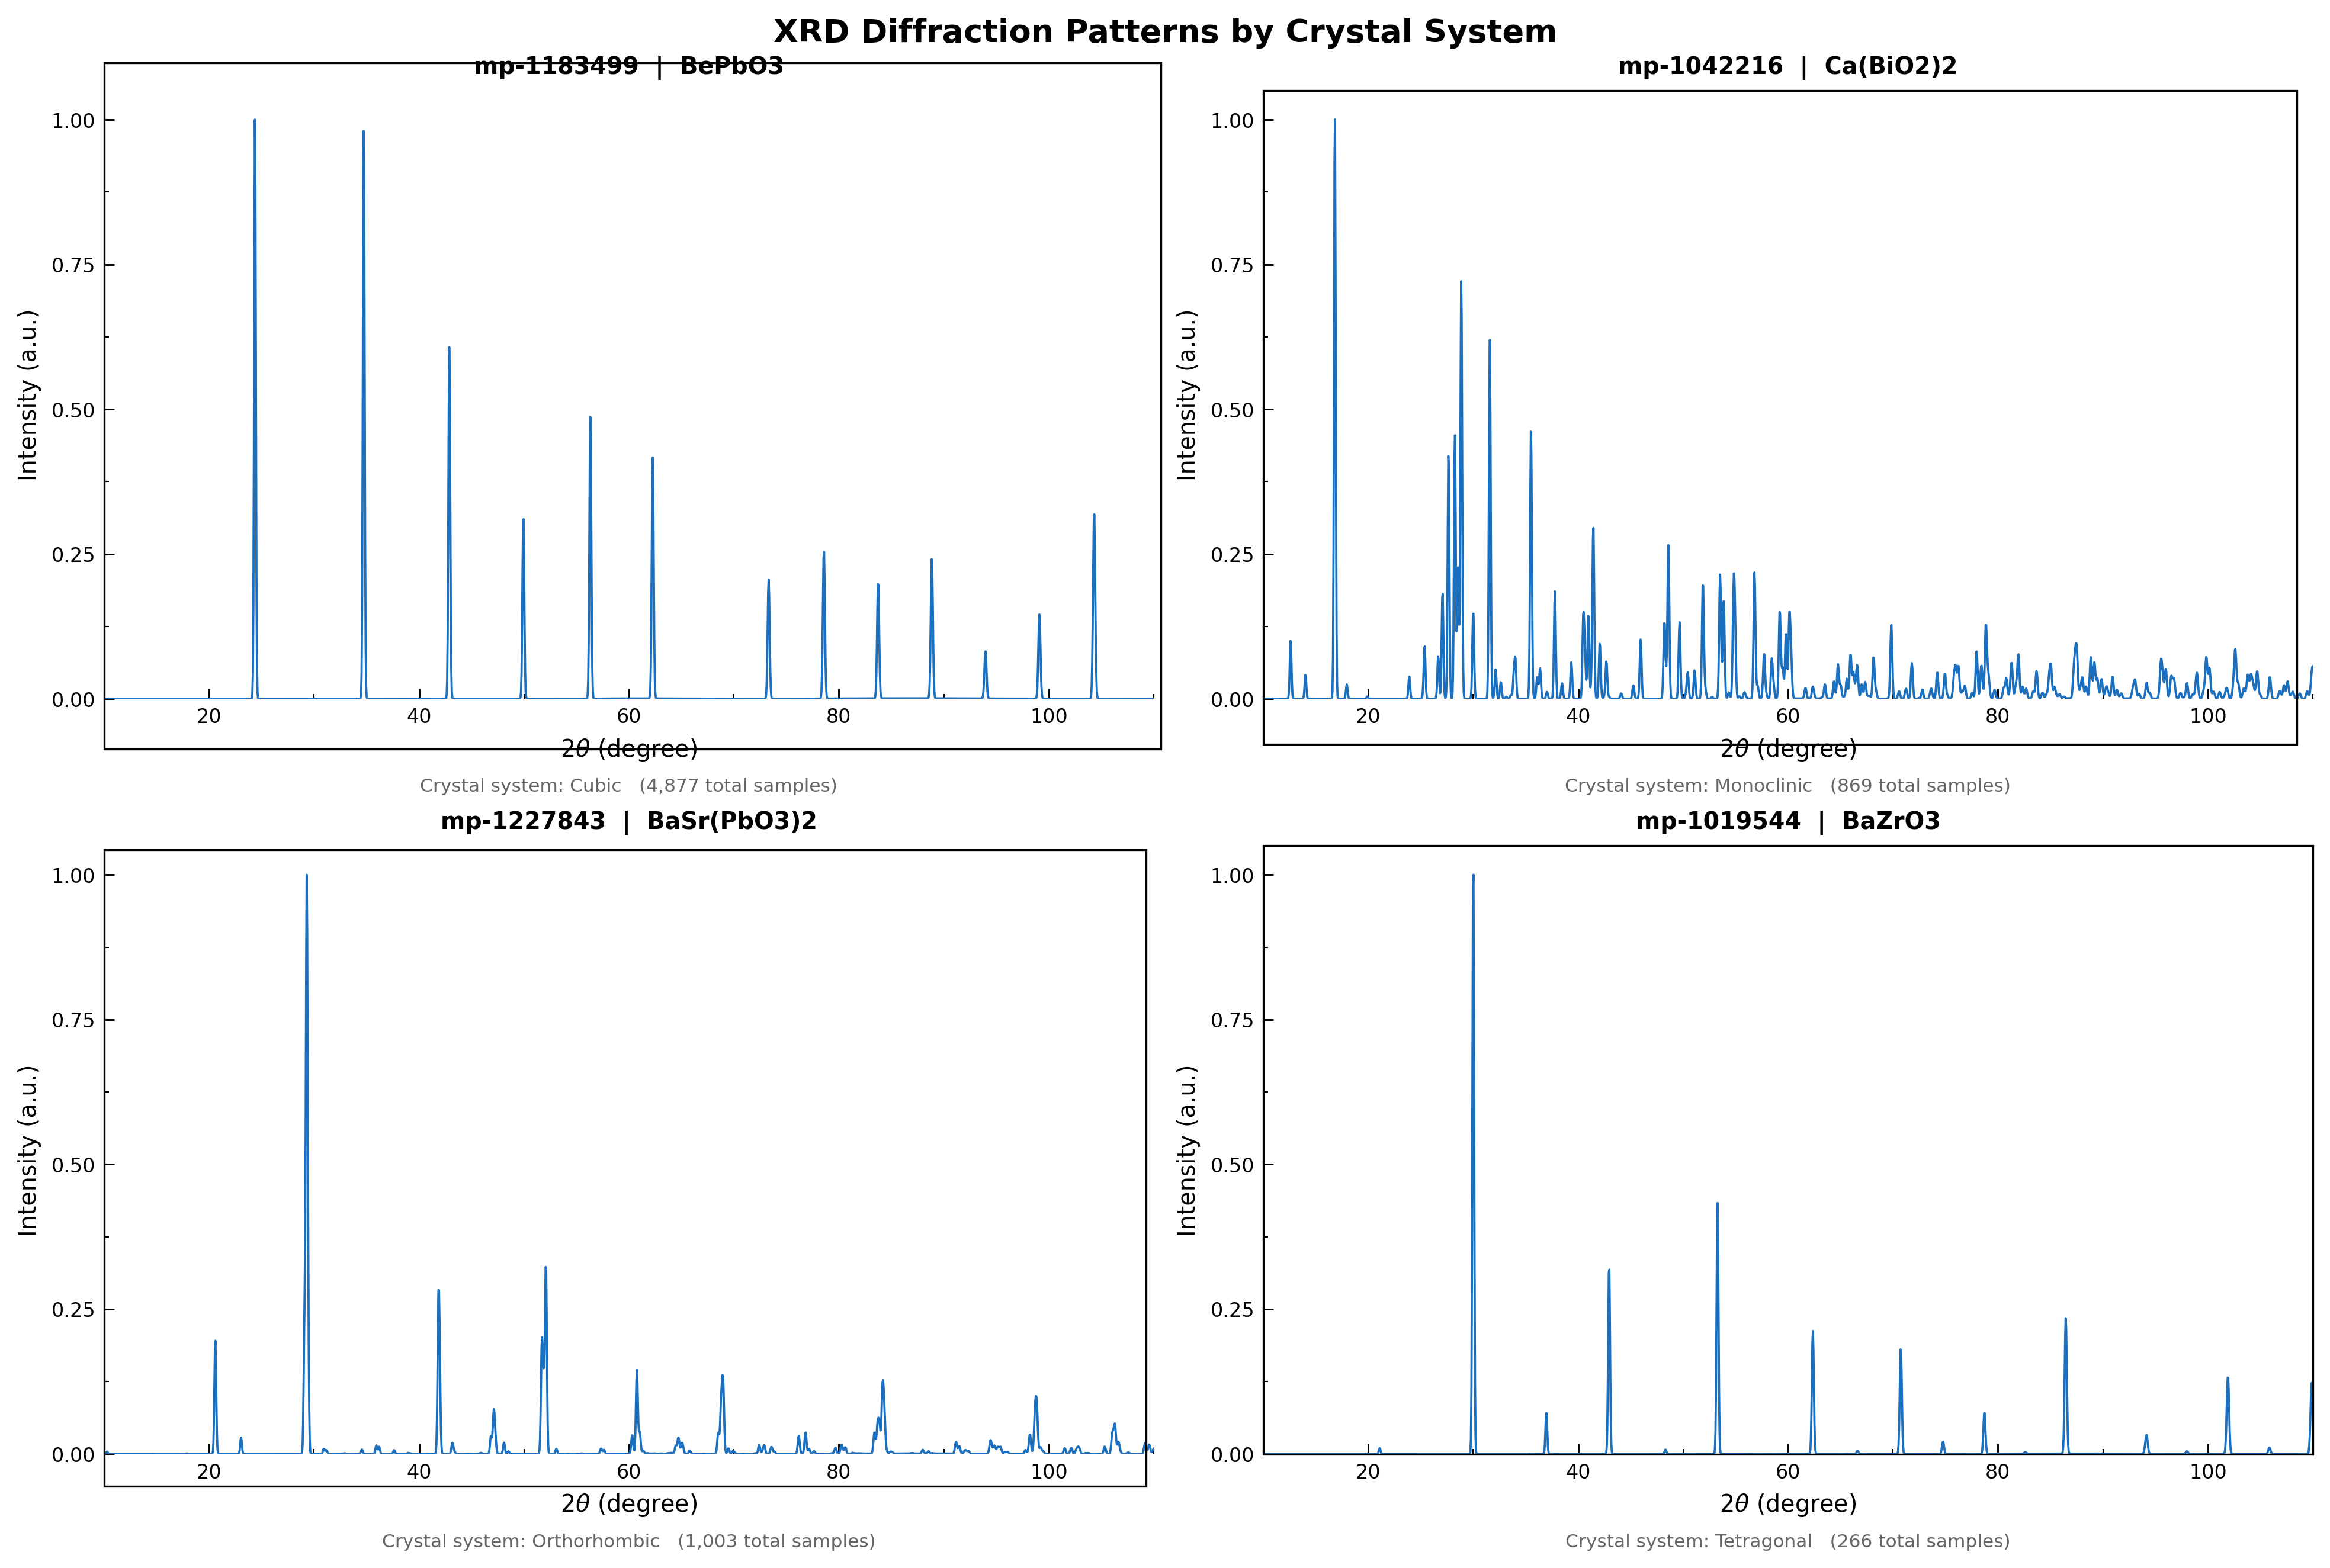


✓ XRD visualisation complete!


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION  ── Blue line, garis tidak keluar kotak
# ============================================================================
import matplotlib.ticker as ticker

def _draw_outer_frame(fig, ax,
                      color=XRD_FRAME_COLOR,
                      lw=XRD_FRAME_WIDTH):
    """Single thin rectangular frame menggantikan default axis spines."""
    fig.canvas.draw()
    x0, y0, w, h = ax.get_position().bounds
    rect = Rectangle(
        (x0, y0), w, h,
        transform=fig.transFigure,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        zorder=10,
    )
    fig.add_artist(rect)


def _style_xrd_ax(ax, fig, title_str,
                  x_min=TWO_THETA_MIN, x_max=TWO_THETA_MAX):
    """Terapkan gaya minimalis ke satu axes XRD."""

    # ── Batas sumbu ─────────────────────────────────────────────────────────
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)          # ← batas atas eksplisit → garis tidak melebihi kotak

    ax.set_xlabel(r"2$\theta$ (degree)", fontsize=9.5, labelpad=4)
    ax.set_ylabel("Intensity (a.u.)",    fontsize=9.5, labelpad=4)

    # ── Tick: ke dalam, major setiap 20°, minor setiap 10° ─────────────────
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))
    ax.tick_params(axis="both", which="major",
                   direction="in", length=4, width=0.7, labelsize=8)
    ax.tick_params(axis="both", which="minor",
                   direction="in", length=2, width=0.5)

    # ── Clip on: garis XRD tidak boleh melewati batas axes ─────────────────
    ax.set_clip_on(True)
    for line in ax.get_lines():
        line.set_clip_on(True)

    # ── Hapus semua spine default ──────────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── Frame kotak tunggal ────────────────────────────────────────────────
    _draw_outer_frame(fig, ax)

    # ── Judul di atas kotak ────────────────────────────────────────────────
    ax.set_title(title_str,
                 fontsize=9.5, fontweight="bold",
                 pad=7, loc="center")


# ── Visualisasi utama ──────────────────────────────────────────────────────
print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION  —  Blue Line, Clipped to Frame")
print("="*70)

np.random.seed(SEED)

fig, axes = plt.subplots(2, 2,
                         figsize=(13, 8.5),
                         dpi=XRD_DPI,
                         constrained_layout=True)
axes_flat = axes.ravel()

for i, system in enumerate(TARGET_SYSTEMS):
    ax  = axes_flat[i]
    idx = np.where(y_str == system)[0]
    print(f"  {system.capitalize():>14s}: {len(idx):>5d} samples")

    if len(idx) == 0:
        ax.set_visible(False)
        continue

    sample_i = idx[0]
    formula  = formulas[sample_i]
    mid      = material_ids[sample_i]

    # ── Plot garis biru, clip_on=True ─────────────────────────────────────
    ax.plot(two_theta_grid, X_raw[sample_i],
            color=XRD_LINE_COLOR,
            linewidth=XRD_LINE_WIDTH,
            clip_on=True,           # ← garis di-clip ke batas axes
            rasterized=False)

    # ── Terapkan gaya ──────────────────────────────────────────────────────
    _style_xrd_ax(ax, fig, f"{mid}  |  {formula}")

    # ── Sub-caption di bawah kotak ─────────────────────────────────────────
    ax.annotate(
        f"Crystal system: {system.capitalize()}   ({len(idx):,} total samples)",
        xy=(0.5, -0.13), xycoords="axes fraction",
        ha="center", va="top",
        fontsize=7.5, color="#666666",
        annotation_clip=False,
    )

fig.suptitle("XRD Diffraction Patterns by Crystal System",
             fontsize=13, fontweight="bold", y=1.02)

plt.show()
print("\n✓ XRD visualisation complete!")